In [ ]:
# Installation des packages nécessaires (à décommenter si besoin)
!pip install kagglehub[pandas-datasets] statsmodels arch scipy matplotlib seaborn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 981.3/981.3 kB 7.9 MB/s eta 0:00:00


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Statsmodels pour ARIMA et VAR
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.api import VAR
from statsmodels.tsa.stattools import adfuller

# Arch pour le modèle GARCH
from arch import arch_model

# Scipy pour la théorie des valeurs extrêmes (EVT)
from scipy.stats import genextreme

import warnings
warnings.filterwarnings("ignore")

# Configuration des graphiques
plt.style.use('seaborn-v0_8-darkgrid')
plt.rcParams['figure.figsize'] = (14, 6)

In [ ]:
import kagglehub
import pandas as pd
import os

print("--- Téléchargement du dataset Bitcoin ---")
# 1. On télécharge tout le dossier du dataset
DATA_DIR = kagglehub.dataset_download("mczielinski/bitcoin-historical-data")
print("Dossier téléchargé avec succès à l'emplacement :")
print(DATA_DIR)

# 2. On liste les fichiers présents dans le dossier téléchargé
fichiers = os.listdir(DATA_DIR)
print("\nFichiers disponibles dans le dossier :", fichiers)

# 3. On trouve automatiquement le fichier CSV et on le charge
# (On cherche le premier fichier qui se termine par .csv)
csv_filename = [f for f in fichiers if f.endswith('.csv')][0]
CSV_PATH = os.path.join(DATA_DIR, csv_filename)

print(f"\nChargement des données depuis : {csv_filename} ...")
df_raw = pd.read_csv(CSV_PATH)

print("\nVoici les 5 premières lignes :")
display(df_raw.head())

--- Téléchargement du dataset Bitcoin ---


100%|██████████| 101M/101M [00:00<00:00, 259MB/s] 

Extracting files...


Dossier téléchargé avec succès à l'emplacement :
/root/.cache/kagglehub/datasets/mczielinski/bitcoin-historical-data/versions/549

Fichiers disponibles dans le dossier : ['btcusd_1-min_data.csv']

Chargement des données depuis : btcusd_1-min_data.csv ...

Voici les 5 premières lignes :


,Timestamp,Open,High,Low,Close,Volume
0,1.325412e+09,4.58,4.58,4.58,4.58,0.0
1,1.325412e+09,4.58,4.58,4.58,4.58,0.0
2,1.325412e+09,4.58,4.58,4.58,4.58,0.0
3,1.325412e+09,4.58,4.58,4.58,4.58,0.0
4,1.325412e+09,4.58,4.58,4.58,4.58,0.0


--- Préparation des données ---
Colonnes détectées dans le fichier : ['Timestamp', 'Open', 'High', 'Low', 'Close', 'Volume']

Données prêtes ! Voici les 5 premières lignes :


,Close,Volume,Log_Returns
Timestamp,,,
2012-01-02,5.00,10.100000,0.032523
2012-01-03,5.29,107.085281,0.056380
2012-01-04,5.57,107.233260,0.051577
2012-01-05,6.42,70.328742,0.142023
2012-01-06,6.40,55.855834,-0.003120


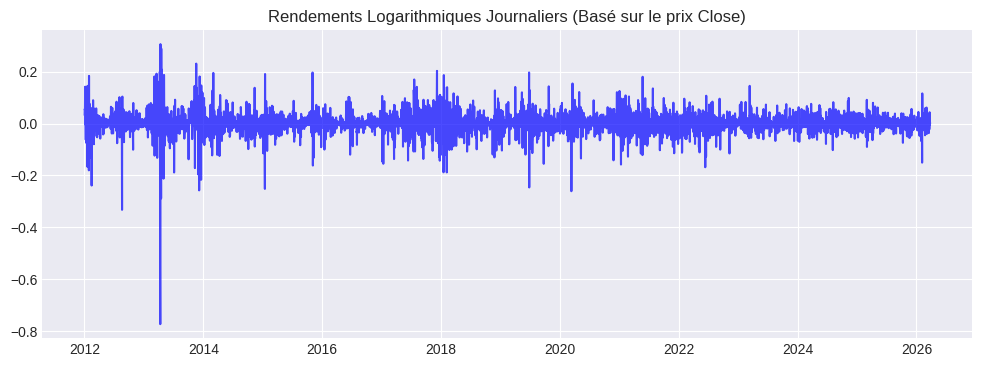

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

print("--- Préparation des données ---")
df = df_raw.copy()

# Affichage des colonnes pour info
print("Colonnes détectées dans le fichier :", df.columns.tolist())

# 1. Gestion du Timestamp (parfois appelé 'Date' ou 'Timestamp')
if 'Timestamp' in df.columns:
    df['Timestamp'] = pd.to_datetime(df['Timestamp'], unit='s')
    df.set_index('Timestamp', inplace=True)
elif 'Date' in df.columns:
    df['Date'] = pd.to_datetime(df['Date'])
    df.set_index('Date', inplace=True)

# 2. Nettoyage : On utilise 'Close' (le prix de clôture) au lieu de 'Weighted_Price'
df['Close'] = df['Close'].ffill()

# Détection automatique du nom de la colonne de Volume
vol_col = 'Volume_(BTC)' if 'Volume_(BTC)' in df.columns else 'Volume'
if vol_col in df.columns:
    df[vol_col] = df[vol_col].fillna(0)

# 3. Rééchantillonnage en données JOURNALIÈRES
# On garde le dernier prix de la journée (Close)
df_daily = df['Close'].resample('D').last().to_frame()

if vol_col in df.columns:
    df_daily['Volume'] = df[vol_col].resample('D').sum()

df_daily.dropna(inplace=True)

# 4. Calcul des rendements logarithmiques sur le prix de clôture
df_daily['Log_Returns'] = np.log(df_daily['Close'] / df_daily['Close'].shift(1))
df_daily.dropna(inplace=True)

print("\nDonnées prêtes ! Voici les 5 premières lignes :")
display(df_daily.head())

# Visualisation
plt.figure(figsize=(12, 4))
plt.plot(df_daily.index, df_daily['Log_Returns'], color='blue', alpha=0.7)
plt.title('Rendements Logarithmiques Journaliers (Basé sur le prix Close)')
plt.show()

--- Modélisation ARIMA(1,1,1) ---
                               SARIMAX Results                                
Dep. Variable:                  Close   No. Observations:                 5198
Model:                 ARIMA(1, 1, 1)   Log Likelihood                9159.353
Date:                Thu, 26 Mar 2026   AIC                         -18312.706
Time:                        15:40:43   BIC                         -18293.038
Sample:                    01-02-2012   HQIC                        -18305.826
                         - 03-26-2026                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.3039      3.882      0.078      0.938      -7.305       7.913
ma.L1         -0.3056      3.881     -0.079      0.937      -7.913       7.302
sigma2         0.0

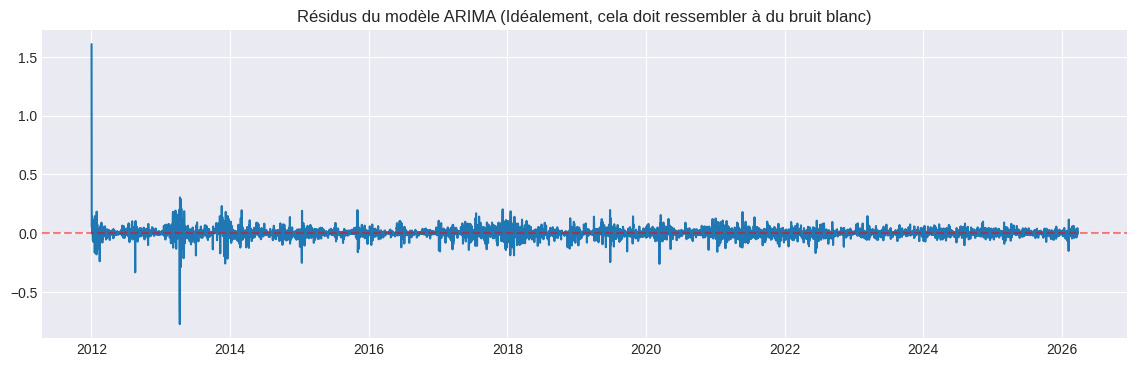

In [ ]:
from statsmodels.tsa.arima.model import ARIMA
import warnings
warnings.filterwarnings("ignore")

print("--- Modélisation ARIMA(1,1,1) ---")

# On travaille sur le logarithme du prix de clôture pour stabiliser la variance
log_price = np.log(df_daily['Close'])

# On lance un modèle ARIMA avec p=1 (1 jour de retard), d=1 (différenciation première), q=1 (moyenne mobile 1 jour)
arima_model = ARIMA(log_price, order=(1, 1, 1))
arima_result = arima_model.fit()

print(arima_result.summary())

# Visualisation des résidus (ce que le modèle n'arrive pas à expliquer)
plt.figure(figsize=(14, 4))
plt.plot(arima_result.resid)
plt.axhline(0, color='red', linestyle='--', alpha=0.5)
plt.title("Résidus du modèle ARIMA (Idéalement, cela doit ressembler à du bruit blanc)")
plt.show()

--- Modélisation GARCH(1,1) ---
                     Constant Mean - GARCH Model Results                      
Dep. Variable:            Log_Returns   R-squared:                       0.000
Mean Model:             Constant Mean   Adj. R-squared:                  0.000
Vol Model:                      GARCH   Log-Likelihood:               -13615.7
Distribution:                  Normal   AIC:                           27239.3
Method:            Maximum Likelihood   BIC:                           27265.6
                                        No. Observations:                 5198
Date:                Thu, Mar 26 2026   Df Residuals:                     5197
Time:                        15:41:04   Df Model:                            1
                                Mean Model                                
                 coef    std err          t      P>|t|    95.0% Conf. Int.
--------------------------------------------------------------------------
mu             0.1230  3.847e-02

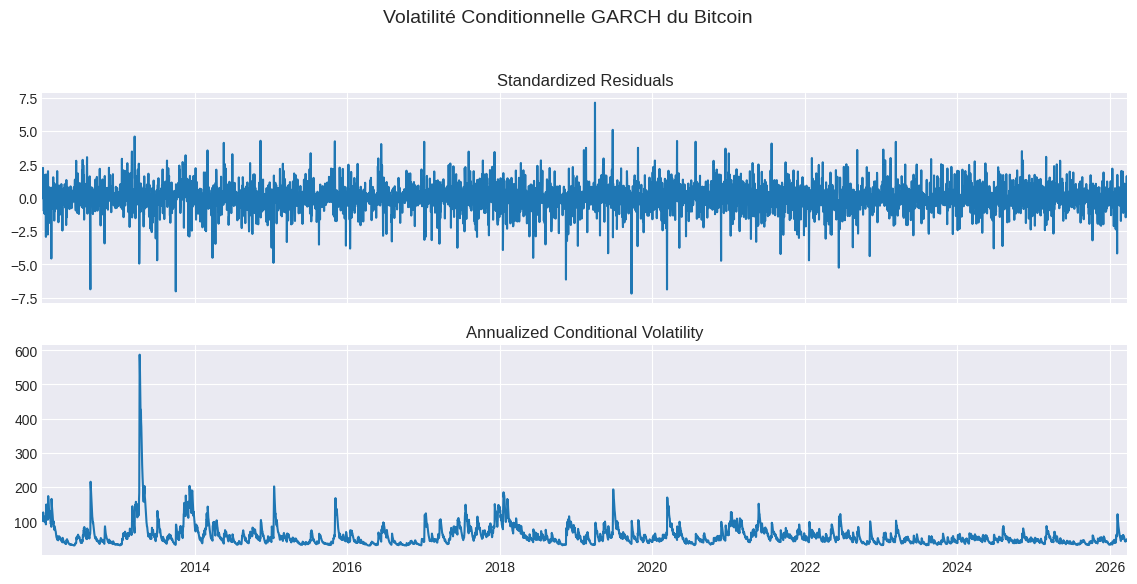

In [ ]:
from arch import arch_model

print("--- Modélisation GARCH(1,1) ---")

# Les modèles GARCH fonctionnent mieux mathématiquement avec des pourcentages (rendements * 100)
returns_scaled = df_daily['Log_Returns'] * 100

# Définition du modèle GARCH(1,1)
garch_model = arch_model(returns_scaled, vol='GARCH', p=1, q=1, mean='Constant')
garch_result = garch_model.fit(disp='off')

print(garch_result.summary())

# Affichage de la volatilité estimée par le modèle
fig = garch_result.plot(annualize='D')
fig.set_size_inches(14, 6)
plt.suptitle("Volatilité Conditionnelle GARCH du Bitcoin", y=1.02, fontsize=14)
plt.show()

--- Modélisation VAR (Multivariée) ---
  Summary of Regression Results   
Model:                         VAR
Method:                        OLS
Date:           Thu, 26, Mar, 2026
Time:                     15:41:22
--------------------------------------------------------------------
No. of Equations:         2.00000    BIC:                   -7.23726
Nobs:                     5194.00    HQIC:                  -7.24875
Log likelihood:           4115.13    FPE:                0.000706680
AIC:                     -7.25493    Det(Omega_mle):     0.000704779
--------------------------------------------------------------------
Results for equation Returns
                        coefficient       std. error           t-stat            prob
-------------------------------------------------------------------------------------
const                      0.001932         0.000576            3.357           0.001
L1.Returns                 0.012075         0.013877            0.870           0.384

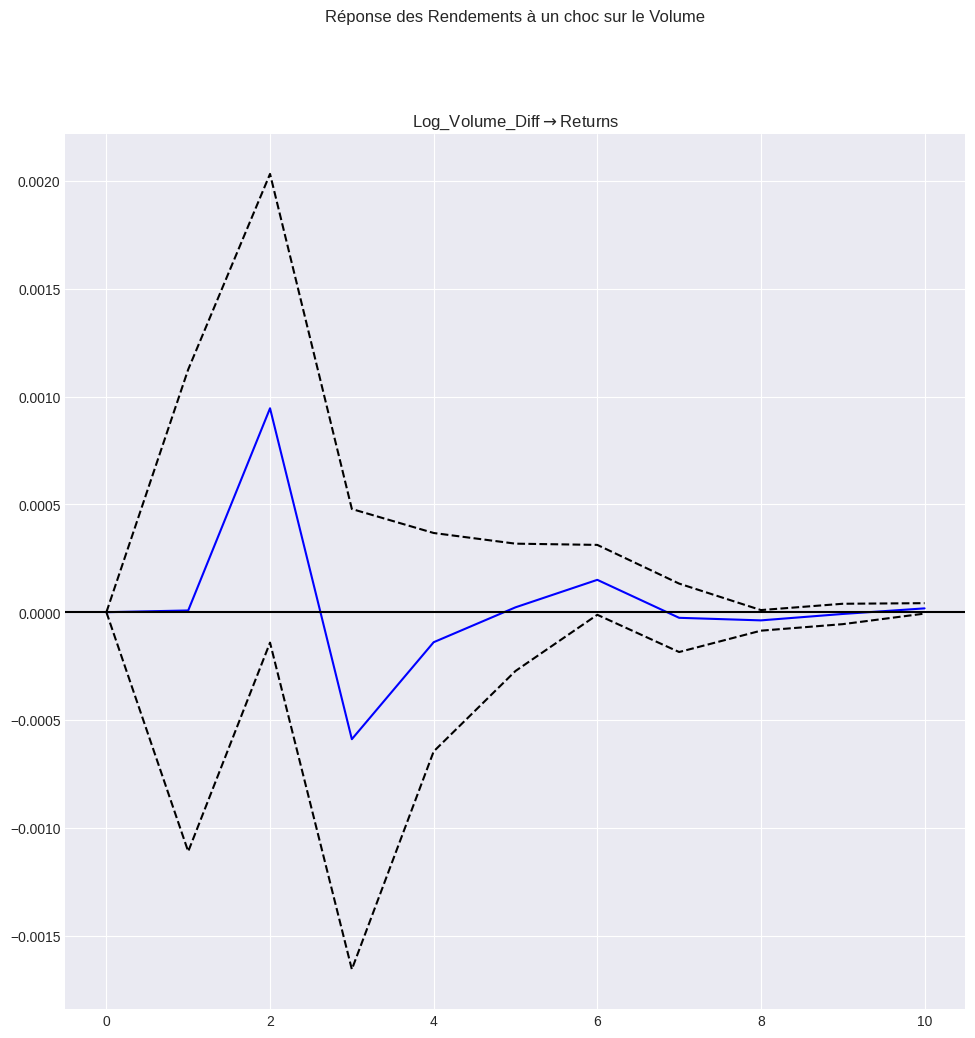

In [ ]:
from statsmodels.tsa.api import VAR

print("--- Modélisation VAR (Multivariée) ---")

# On vérifie qu'on a bien récupéré le volume à l'étape précédente
if 'Volume' in df_daily.columns:
    # Préparation d'un DataFrame bivarié (Rendements et Volumes)
    # On passe le volume en log et on le différencie pour qu'il soit stationnaire
    df_var = pd.DataFrame({
        'Returns': df_daily['Log_Returns'],
        'Log_Volume_Diff': np.log(df_daily['Volume'] + 1).diff()
    }).dropna()

    # Initialisation et ajustement du modèle avec 3 jours de retard (lags)
    model_var = VAR(df_var)
    var_result = model_var.fit(3)

    print(var_result.summary())

    # Graphique de réponse impulsionnelle (IRF)
    # Que se passe-t-il sur les rendements si le volume subit un choc soudain ?
    irf = var_result.irf(10) # Sur 10 jours
    irf.plot(orth=True, impulse='Log_Volume_Diff', response='Returns')
    plt.suptitle("Réponse des Rendements à un choc sur le Volume", y=1.05)
    plt.show()
else:
    print("La colonne Volume n'est pas présente dans les données, modèle VAR ignoré.")

--- Analyse des Valeurs Extrêmes (EVT) ---
Paramètres GEV ajustés :
- Shape (xi) = -0.2821 (Définit l'épaisseur de la queue du krach)
- Loc (mu) = 0.0552
- Scale (sigma) = 0.0325


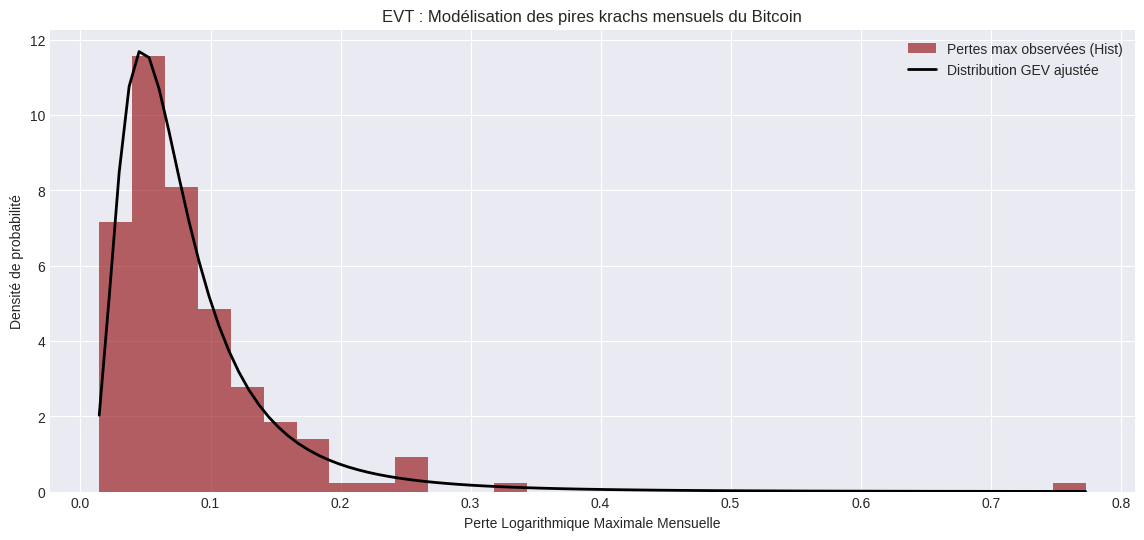

In [ ]:
from scipy.stats import genextreme

print("--- Analyse des Valeurs Extrêmes (EVT) ---")

# On s'intéresse aux pires pertes (on prend l'opposé des rendements)
losses = -df_daily['Log_Returns']

# Méthode des Block Maxima : on extrait la pire journée de chaque mois
# On utilise 'ME' (Month End) pour le resampling pandas récent
monthly_max_losses = losses.resample('ME').max().dropna()

# Ajustement de la distribution GEV (Generalized Extreme Value)
shape, loc, scale = genextreme.fit(monthly_max_losses)
print(f"Paramètres GEV ajustés :\n- Shape (xi) = {shape:.4f} (Définit l'épaisseur de la queue du krach)\n- Loc (mu) = {loc:.4f}\n- Scale (sigma) = {scale:.4f}")

# Visualisation : Histogramme vs Distribution théorique
plt.figure(figsize=(14, 6))
plt.hist(monthly_max_losses, bins=30, density=True, alpha=0.6, color='darkred', label='Pertes max observées (Hist)')

x_var = np.linspace(monthly_max_losses.min(), monthly_max_losses.max(), 100)
plt.plot(x_var, genextreme.pdf(x_var, shape, loc, scale), 'k-', lw=2, label='Distribution GEV ajustée')

plt.title("EVT : Modélisation des pires krachs mensuels du Bitcoin")
plt.xlabel("Perte Logarithmique Maximale Mensuelle")
plt.ylabel("Densité de probabilité")
plt.legend()
plt.show()

--- Backtesting ARIMA : L'épreuve de vérité ---
Période d'entraînement (Train) : 5108 jours
Période de validation (Test) : 90 jours

Entraînement du modèle en cours...
Erreur RMSE (sur l'échelle logarithmique) : 0.1838


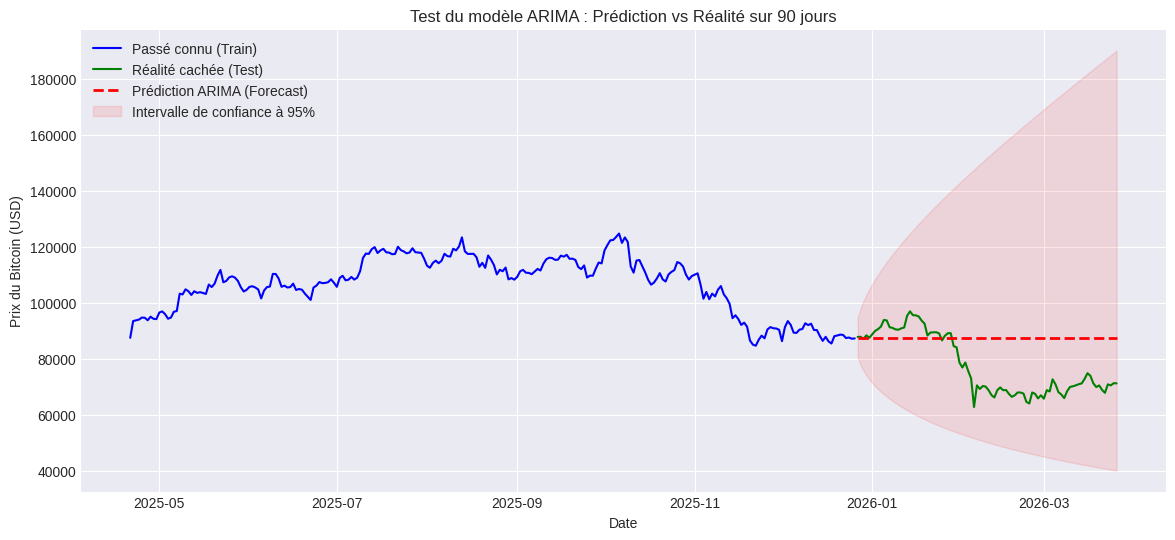

In [ ]:
# BACKTESTING

from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt
import numpy as np

print("--- Backtesting ARIMA : L'épreuve de vérité ---")

# On utilise la série temporelle du logarithme des prix
data = np.log(df_daily['Close']).dropna()

# 1. Découpage : on garde les 90 derniers jours pour le Test
n_test = 90
train = data.iloc[:-n_test]
test = data.iloc[-n_test:]

print(f"Période d'entraînement (Train) : {len(train)} jours")
print(f"Période de validation (Test) : {len(test)} jours")

# 2. Entraînement du modèle UNIQUEMENT sur les données d'entraînement
print("\nEntraînement du modèle en cours...")
model = ARIMA(train, order=(1, 1, 1))
fitted_model = model.fit()

# 3. Prédiction (Forecasting) sur les 90 jours suivants
forecast = fitted_model.forecast(steps=n_test)
forecast.index = test.index # On aligne les dates

# 4. Calcul de l'erreur mathématique (RMSE - Root Mean Squared Error)
rmse = np.sqrt(mean_squared_error(test, forecast))
print(f"Erreur RMSE (sur l'échelle logarithmique) : {rmse:.4f}")

# 5. Visualisation (On repasse en prix normaux avec np.exp() pour que ce soit lisible)
train_price = np.exp(train)
test_price = np.exp(test)
forecast_price = np.exp(forecast)

plt.figure(figsize=(14, 6))

# On n'affiche que la dernière année d'entraînement pour ne pas écraser le graphique
plt.plot(train_price.iloc[-250:], label='Passé connu (Train)', color='blue')
plt.plot(test_price, label='Réalité cachée (Test)', color='green')
plt.plot(forecast_price, label='Prédiction ARIMA (Forecast)', color='red', linestyle='--', linewidth=2)

# Remplissage de l'intervalle de confiance (optionnel mais très pro)
pred_summary = fitted_model.get_forecast(steps=n_test).summary_frame()
conf_int_lower = np.exp(pred_summary['mean_ci_lower'])
conf_int_upper = np.exp(pred_summary['mean_ci_upper'])
plt.fill_between(test.index, conf_int_lower, conf_int_upper, color='red', alpha=0.1, label='Intervalle de confiance à 95%')

plt.title("Test du modèle ARIMA : Prédiction vs Réalité sur 90 jours")
plt.xlabel("Date")
plt.ylabel("Prix du Bitcoin (USD)")
plt.legend()
plt.show()

--- Backtesting GARCH & EVT sur les 90 derniers jours ---
Période d'entraînement : 5108 jours
Période de test cachée : 90 jours

1. Entraînement et Prédiction GARCH...


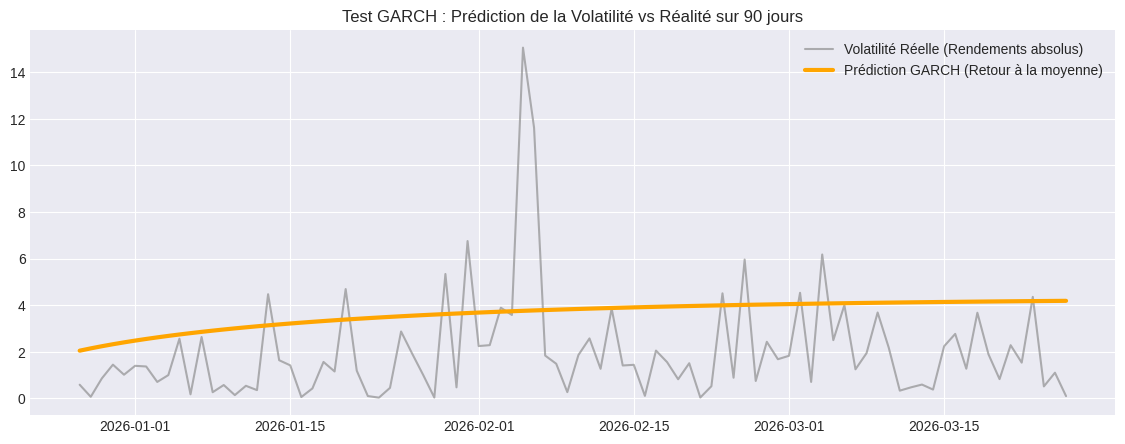


2. Entraînement et Validation EVT...
------------------------------------------------------------
Prédiction EVT : La pire chute mensuelle attendue sur cette période était de -8.48 %
Réalité (Test) : La pire chute observée dans les 90 jours a été de -13.98 %
⚠️ ALERTE : Le marché a crashé plus fort que prévu par l'EVT (Événement extrême rare !)
------------------------------------------------------------


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from arch import arch_model
from scipy.stats import genextreme

print("--- Backtesting GARCH & EVT sur les 90 derniers jours ---")

# 1. SEGMENTATION (Train / Test Split)
n_test = 90
returns_scaled = df_daily['Log_Returns'] * 100 # Rendements en pourcentages
train_ret = returns_scaled.iloc[:-n_test]
test_ret = returns_scaled.iloc[-n_test:]

print(f"Période d'entraînement : {len(train_ret)} jours")
print(f"Période de test cachée : {len(test_ret)} jours\n")

# ==========================================
# PARTIE 1 : BACKTESTING GARCH (Volatilité)
# ==========================================
print("1. Entraînement et Prédiction GARCH...")
garch_model = arch_model(train_ret, vol='GARCH', p=1, q=1, mean='Constant')
garch_res = garch_model.fit(disp='off')

# Prédiction de la variance sur 90 jours
garch_forecast = garch_res.forecast(horizon=n_test)
# On extrait la variance prévue et on la passe en volatilité (écart-type)
pred_volatility = np.sqrt(garch_forecast.variance.iloc[-1].values)

# Pour comparer, on calcule la volatilité "réalisée" (absolue) du test set
realized_volatility = np.abs(test_ret.values)

plt.figure(figsize=(14, 5))
plt.plot(test_ret.index, realized_volatility, color='grey', alpha=0.6, label='Volatilité Réelle (Rendements absolus)')
plt.plot(test_ret.index, pred_volatility, color='orange', linewidth=3, label='Prédiction GARCH (Retour à la moyenne)')
plt.title("Test GARCH : Prédiction de la Volatilité vs Réalité sur 90 jours")
plt.legend()
plt.show()

# ==========================================
# PARTIE 2 : BACKTESTING EVT (Risque Extrême)
# ==========================================
print("\n2. Entraînement et Validation EVT...")
# On entraîne l'EVT uniquement sur le passé (train)
train_losses = -train_ret / 100 # On repasse en log-returns normaux pour l'EVT
monthly_max_losses_train = train_losses.resample('ME').max().dropna()

shape_t, loc_t, scale_t = genextreme.fit(monthly_max_losses_train)

# On calcule le niveau de retour pour 1 trimestre (3 mois = la taille de notre test set)
p_trimestre = 1 - (1 / 3)
pire_krach_prevu = genextreme.ppf(p_trimestre, shape_t, loc=loc_t, scale=scale_t)
pire_krach_prevu_pct = (1 - np.exp(-pire_krach_prevu)) * 100

# On regarde ce qui s'est VRAIMENT passé dans le Test set
pire_krach_reel = -test_ret.min() # test_ret est déjà en %
pire_chute_pct = (1 - np.exp(-pire_krach_reel/100)) * 100

print("-" * 60)
print(f"Prédiction EVT : La pire chute mensuelle attendue sur cette période était de -{pire_krach_prevu_pct:.2f} %")
print(f"Réalité (Test) : La pire chute observée dans les 90 jours a été de -{pire_chute_pct:.2f} %")

if pire_chute_pct > pire_krach_prevu_pct:
    print("⚠️ ALERTE : Le marché a crashé plus fort que prévu par l'EVT (Événement extrême rare !)")
else:
    print("✅ SUCCÈS : Le pire krach des 90 jours est resté dans les limites du risque calculé.")
print("-" * 60)

In [ ]:
import pandas as pd

print("--- VÉRIFICATION STATISTIQUE DES MODÈLES (P-VALUES) ---")
seuil_significativite = 0.05

def analyser_pvalues(pvalues, nom_modele):
    print(f"\n[{nom_modele}] - Analyse des coefficients :")
    print("-" * 50)

    # On parcourt chaque paramètre et sa p-value
    for parametre, pval in pvalues.items():
        # Formatage pour l'affichage
        statut = "✅ SIGNIFICATIF" if pval < seuil_significativite else "❌ NON SIGNIFICATIF"

        print(f"Paramètre: {parametre:<12} | P-value: {pval:.4f} | {statut}")
    print("-" * 50)

# ==========================================
# 1. P-values du modèle ARIMA
# ==========================================
# (On utilise l'objet fitted_model de la Cellule 9)
try:
    analyser_pvalues(fitted_model.pvalues, "Modèle ARIMA (Tendance)")
except NameError:
    print("Modèle ARIMA non trouvé. As-tu bien exécuté la cellule d'entraînement ARIMA ?")

# ==========================================
# 2. P-values du modèle GARCH
# ==========================================
# (On utilise l'objet garch_res de la Cellule 11)
try:
    analyser_pvalues(garch_res.pvalues, "Modèle GARCH (Volatilité)")
except NameError:
    print("Modèle GARCH non trouvé. As-tu bien exécuté la cellule d'entraînement GARCH ?")

print("\n💡 Interprétation :")
print("- ✅ Si < 0.05 : Le paramètre joue un vrai rôle. On le garde.")
print("- ❌ Si > 0.05 : Le paramètre est inutile (bruit). Le modèle est peut-être mal calibré.")

--- VÉRIFICATION STATISTIQUE DES MODÈLES (P-VALUES) ---

[Modèle ARIMA (Tendance)] - Analyse des coefficients :
--------------------------------------------------
Paramètre: ar.L1        | P-value: 0.9203 | ❌ NON SIGNIFICATIF
Paramètre: ma.L1        | P-value: 0.9212 | ❌ NON SIGNIFICATIF
Paramètre: sigma2       | P-value: 0.0000 | ✅ SIGNIFICATIF
--------------------------------------------------

[Modèle GARCH (Volatilité)] - Analyse des coefficients :
--------------------------------------------------
Paramètre: mu           | P-value: 0.0015 | ✅ SIGNIFICATIF
Paramètre: omega        | P-value: 0.0003 | ✅ SIGNIFICATIF
Paramètre: alpha[1]     | P-value: 0.0000 | ✅ SIGNIFICATIF
Paramètre: beta[1]      | P-value: 0.0000 | ✅ SIGNIFICATIF
--------------------------------------------------

💡 Interprétation :
- ✅ Si < 0.05 : Le paramètre joue un vrai rôle. On le garde.
- ❌ Si > 0.05 : Le paramètre est inutile (bruit). Le modèle est peut-être mal calibré.


logique pour bitcoin (les marchés prédisent pas l'avenir etc)

💰 RAPPORT DE GESTION DES RISQUES (Horizon : 1 Jour) 💰

--- MÉTHODE HISTORIQUE (Basée sur tout le passé) ---
📉 Value at Risk (VaR 99%) : Pire chute prévue = -11.95%
   -> Sur un capital de 10000$, on a 99% de chances de NE PAS PERDRE PLUS DE 1195.12 $ demain.
🔥 Expected Shortfall (ES 99%) : Si le pire arrive (le 1% restant)...
   -> La perte moyenne estimée sera de -18.53% (soit 1852.61 $).

--- MÉTHODE GARCH (Prédiction spécifique pour demain) ---
📉 Value at Risk (VaR 99%) : Pire chute prévue = -5.80%
   -> Sur un capital de 10000$, on a 99% de chances de NE PAS PERDRE PLUS DE 579.52 $ demain.
🔥 Expected Shortfall (ES 99%) : Si le pire arrive (le 1% restant)...
   -> La perte moyenne estimée sera de -6.66% (soit 665.72 $).



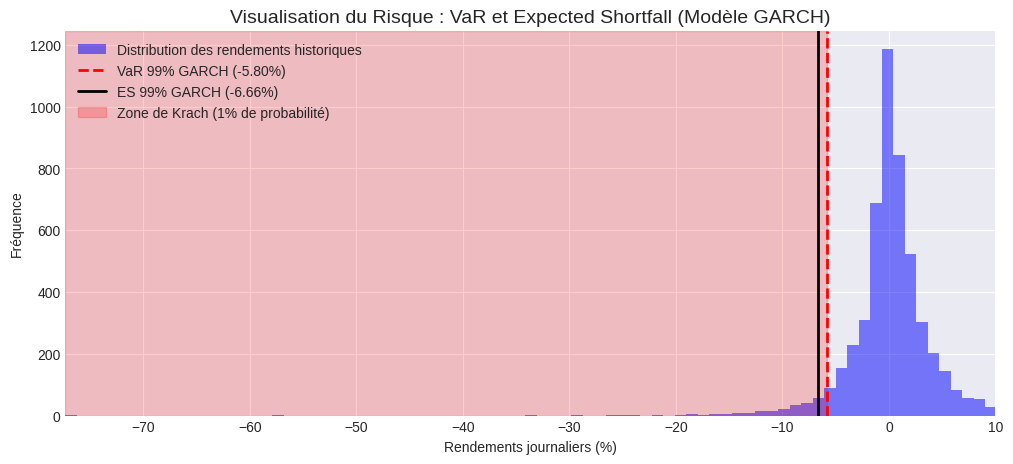

In [ ]:
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt

print("======================================================")
print("💰 RAPPORT DE GESTION DES RISQUES (Horizon : 1 Jour) 💰")
print("======================================================\n")

# Paramètres du portefeuille pour le côté "Business"
valeur_portefeuille = 10000  # $10,000
seuil_confiance = 0.99
alpha = 1 - seuil_confiance # 0.01 (1%)

# On récupère les rendements en pourcentages
returns_pct = df_daily['Log_Returns'].dropna() * 100

# ---------------------------------------------------------
# 1. MÉTHODE HISTORIQUE (Le filet de sécurité empirique)
# ---------------------------------------------------------
# VaR : Le quantile à 1% des pires rendements passés
var_99_hist = np.percentile(returns_pct, alpha * 100)

# ES : La moyenne de toutes les pertes qui sont pires que la VaR
es_99_hist = returns_pct[returns_pct <= var_99_hist].mean()

# ---------------------------------------------------------
# 2. MÉTHODE GARCH (Prédiction dynamique pour DEMAIN)
# ---------------------------------------------------------
# On demande au modèle GARCH (entraîné en cellule 6) de prédire la volatilité de demain
garch_forecast = garch_result.forecast(horizon=1)
mu_demain = garch_forecast.mean.iloc[-1, 0]
sigma_demain = np.sqrt(garch_forecast.variance.iloc[-1, 0])

# Calcul de la VaR Paramétrique (basée sur la loi normale)
z_score = stats.norm.ppf(alpha) # Environ -2.33 pour 1%
var_99_garch = mu_demain + (sigma_demain * z_score)

# Calcul de l'Expected Shortfall Paramétrique
# Formule mathématique exacte pour la queue d'une loi normale
es_99_garch = mu_demain - (sigma_demain * (stats.norm.pdf(z_score) / alpha))

# ---------------------------------------------------------
# AFFICHAGE DES RÉSULTATS BUSINESS
# ---------------------------------------------------------
def afficher_metriques(nom_methode, var_pct, es_pct, capital):
    var_usd = capital * (abs(var_pct) / 100)
    es_usd = capital * (abs(es_pct) / 100)

    print(f"--- {nom_methode} ---")
    print(f"📉 Value at Risk (VaR 99%) : Pire chute prévue = {var_pct:.2f}%")
    print(f"   -> Sur un capital de {capital}$, on a 99% de chances de NE PAS PERDRE PLUS DE {var_usd:.2f} $ demain.")
    print(f"🔥 Expected Shortfall (ES 99%) : Si le pire arrive (le 1% restant)...")
    print(f"   -> La perte moyenne estimée sera de {es_pct:.2f}% (soit {es_usd:.2f} $).")
    print("")

afficher_metriques("MÉTHODE HISTORIQUE (Basée sur tout le passé)", var_99_hist, es_99_hist, valeur_portefeuille)
afficher_metriques("MÉTHODE GARCH (Prédiction spécifique pour demain)", var_99_garch, es_99_garch, valeur_portefeuille)

# ---------------------------------------------------------
# VISUALISATION : La queue de distribution
# ---------------------------------------------------------
plt.figure(figsize=(12, 5))
plt.hist(returns_pct, bins=100, alpha=0.5, color='blue', label='Distribution des rendements historiques')

# Lignes verticales pour la VaR et l'ES (GARCH)
plt.axvline(var_99_garch, color='red', linestyle='dashed', linewidth=2, label=f'VaR 99% GARCH ({var_99_garch:.2f}%)')
plt.axvline(es_99_garch, color='black', linestyle='solid', linewidth=2, label=f'ES 99% GARCH ({es_99_garch:.2f}%)')

# Zone de danger (Le fameux 1%)
plt.axvspan(returns_pct.min(), var_99_garch, color='red', alpha=0.2, label='Zone de Krach (1% de probabilité)')

plt.title("Visualisation du Risque : VaR et Expected Shortfall (Modèle GARCH)", fontsize=14)
plt.xlabel("Rendements journaliers (%)")
plt.ylabel("Fréquence")
plt.legend()
plt.xlim(returns_pct.min(), 10) # On zoome sur les pertes
plt.show()

In [ ]:
from statsmodels.stats.diagnostic import acorr_ljungbox, het_arch
from scipy.stats import jarque_bera
import pandas as pd

print("======================================================")
print("🔍 DIAGNOSTIC DES MODÈLES (Analyse des Résidus) 🔍")
print("======================================================\n")

# Seuil de significativité standard
alpha = 0.05

# 1. Préparation des résidus
# Résidus de l'ARIMA (on enlève la première valeur souvent faussée par l'initialisation)
residus_arima = arima_result.resid.iloc[1:].dropna()

# Résidus standardisés du GARCH (Erreur divisée par la volatilité prédite)
residus_garch_std = (garch_result.resid / garch_result.conditional_volatility).dropna()

# ---------------------------------------------------------
# TEST 1 : Ljung-Box (Test d'Autocorrélation sur l'ARIMA)
# ---------------------------------------------------------
print("--- 1. Test de Ljung-Box (Modèle ARIMA) ---")
print("Question : Reste-t-il de l'information (une tendance cachée) dans les erreurs ?")
# On teste sur 10 retards (lags)
lb_test = acorr_ljungbox(residus_arima, lags=[10], return_df=True)
lb_pval = lb_test['lb_pvalue'].iloc[0]

if lb_pval > alpha:
    print(f"✅ P-value = {lb_pval:.4f} (> 0.05)")
    print("-> SUCCÈS : Les résidus sont un bruit blanc. L'ARIMA a capté toute la tendance.")
else:
    print(f"❌ P-value = {lb_pval:.4f} (< 0.05)")
    print("-> ÉCHEC : Il reste de l'autocorrélation. Le modèle ARIMA pourrait être amélioré.")
print("")

# ---------------------------------------------------------
# TEST 2 : Jarque-Bera (Test de Normalité sur le GARCH)
# ---------------------------------------------------------
print("--- 2. Test de Jarque-Bera (Modèle GARCH) ---")
print("Question : Les erreurs suivent-elles une courbe en cloche parfaite (Loi Normale) ?")
jb_stat, jb_pval = jarque_bera(residus_garch_std)

if jb_pval > alpha:
    print(f"❌ P-value = {jb_pval:.4f} (> 0.05)")
    print("-> Les résidus sont normaux. (Surprenant pour de la crypto !)")
else:
    print(f"✅ P-value = {jb_pval:.4f} (< 0.05)")
    print("-> SUCCÈS LOGIQUE : Les résidus ne sont PAS normaux (Queues épaisses).")
    print("-> Cela justifie parfaitement l'utilisation de la Théorie des Valeurs Extrêmes (EVT) dans notre projet !")
print("")

# ---------------------------------------------------------
# TEST 3 : ARCH-LM (Test d'Hétéroscédasticité sur le GARCH)
# ---------------------------------------------------------
print("--- 3. Test ARCH-LM (Modèle GARCH) ---")
print("Question : Le GARCH a-t-il bien aspiré toute la 'grappe de volatilité' ?")
# On teste s'il reste des effets ARCH sur les résidus standardisés
arch_test = het_arch(residus_garch_std, nlags=5)
arch_pval = arch_test[1] # La p-value est le 2ème élément retourné

if arch_pval > alpha:
    print(f"✅ P-value = {arch_pval:.4f} (> 0.05)")
    print("-> SUCCÈS : Il n'y a plus d'effets ARCH. Le modèle GARCH a parfaitement modélisé la variance.")
else:
    print(f"❌ P-value = {arch_pval:.4f} (< 0.05)")
    print("-> ÉCHEC : Il reste de la volatilité non expliquée. Il faudrait peut-être un GARCH(2,2).")

🔍 DIAGNOSTIC DES MODÈLES (Analyse des Résidus) 🔍

--- 1. Test de Ljung-Box (Modèle ARIMA) ---
Question : Reste-t-il de l'information (une tendance cachée) dans les erreurs ?
❌ P-value = 0.0000 (< 0.05)
-> ÉCHEC : Il reste de l'autocorrélation. Le modèle ARIMA pourrait être amélioré.

--- 2. Test de Jarque-Bera (Modèle GARCH) ---
Question : Les erreurs suivent-elles une courbe en cloche parfaite (Loi Normale) ?
✅ P-value = 0.0000 (< 0.05)
-> SUCCÈS LOGIQUE : Les résidus ne sont PAS normaux (Queues épaisses).
-> Cela justifie parfaitement l'utilisation de la Théorie des Valeurs Extrêmes (EVT) dans notre projet !

--- 3. Test ARCH-LM (Modèle GARCH) ---
Question : Le GARCH a-t-il bien aspiré toute la 'grappe de volatilité' ?
✅ P-value = 0.0817 (> 0.05)
-> SUCCÈS : Il n'y a plus d'effets ARCH. Le modèle GARCH a parfaitement modélisé la variance.


Les crypto-monnaies ont des micro-structures complexes (effets de week-end, comportements grégaires). Un modèle linéaire classique échoue à tout expliquer, prouvant que le marché n'est pas une simple marche aléatoire pure, mais qu'il reste très difficile à prévoir

D'où l'EVT